In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from math import sqrt
import time
import re
from scipy import signal
from scipy.signal import find_peaks
import ipywidgets as widgets
from src.analisi.tools import *

In [2]:
%matplotlib widget
plt.close('all')

In [3]:
# selettore cartella
folder_selector = widgets.Dropdown( 
    options=sorted([f for f in os.listdir(base_img_folder) if os.path.isdir(os.path.join(base_img_folder, f))], reverse=True),
    description='Sessione:',
    style={'description_width': 'initial'}
)

display(folder_selector)

Dropdown(description='Sessione:', options=('percolazione', 'lampadina_test_final', 'lampadina3_test', 'lampadi…

In [4]:
images, image_timestamps = load_images_from_folder(os.path.join(base_img_folder, folder_selector.value, 'images'))
images, image_timestamps = sort_images_and_timestamps(images, image_timestamps)
image_seconds = [time.mktime(time.strptime(ts, FORMATO_COMUNE)) for ts in image_timestamps]
image_seconds = np.array(image_seconds)

In [5]:
print(images[0].dtype)
print(images[0].shape)

images_arr = np.array(images)

print(images_arr.shape)



uint8
(480, 640)
(1076, 480, 640)


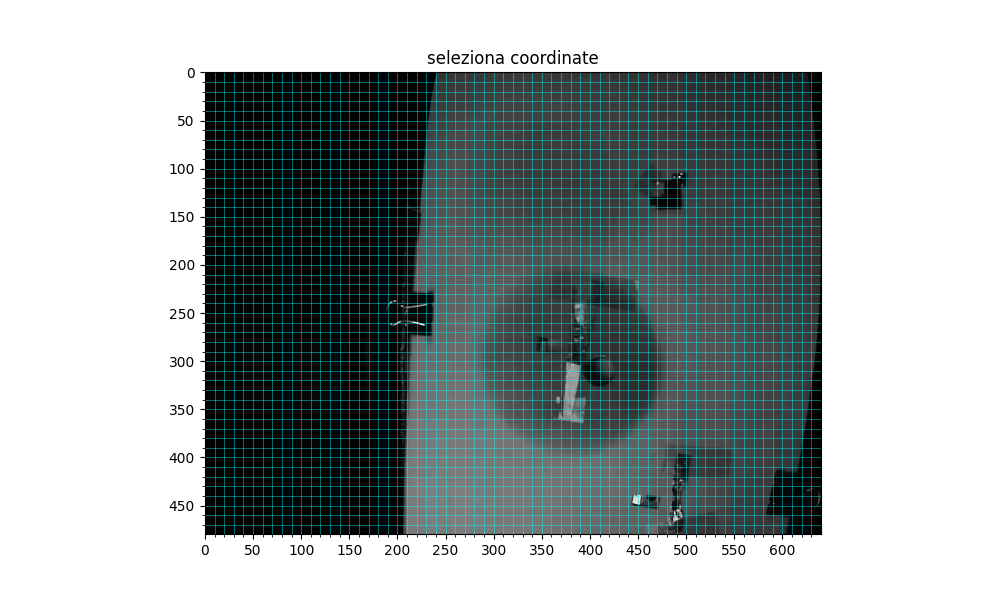

In [6]:
image_sample = images[-1]

plt.figure(figsize=(10,6))
plt.imshow(image_sample, cmap='gray')

plt.xticks(np.arange(0, image_sample.shape[1], 50))
plt.yticks(np.arange(0, image_sample.shape[0], 50))

plt.gca().set_xticks(np.arange(0, image_sample.shape[1], 10), minor=True)
plt.gca().set_yticks(np.arange(0, image_sample.shape[0], 10), minor=True)

plt.grid(visible=True, which='both', color='cyan', linestyle='-', linewidth=0.5, alpha=0.6)
#plt.grid(color='cyan', linestyle='-', linewidth=0.5)
plt.title("seleziona coordinate")
plt.show()

In [7]:
intensita_bianco = [images_arr[i, 245, 474] for i in range(len(images_arr))]
intensita_nero = [images_arr[i, 242, 131] for i in range(len(images_arr))]


"""fft_bianco = np.fft.rfft(intensita_bianco)
powerspectrum_bianco = np.abs(fft_bianco)**2

fft_nero = np.fft.rfft(intensita_nero)
powerspectrum_nero = np.abs(fft_nero)**2

frequenze_bianco = np.fft.rfftfreq(len(intensita_bianco), d=np.mean(np.diff(image_seconds)))
frequenze_nero = np.fft.rfftfreq(len(intensita_nero), d=np.mean(np.diff(image_seconds)))"""


'fft_bianco = np.fft.rfft(intensita_bianco)\npowerspectrum_bianco = np.abs(fft_bianco)**2\n\nfft_nero = np.fft.rfft(intensita_nero)\npowerspectrum_nero = np.abs(fft_nero)**2\n\nfrequenze_bianco = np.fft.rfftfreq(len(intensita_bianco), d=np.mean(np.diff(image_seconds)))\nfrequenze_nero = np.fft.rfftfreq(len(intensita_nero), d=np.mean(np.diff(image_seconds)))'

In [8]:
# x = ntensità del segnale
# fs = la frequenza di campionamento (1 diviso il tempo medio tra i frame)
frequenze_welch_b, powerspectrum_welch_b = signal.welch(intensita_bianco, fs=1.0/np.mean(np.diff(image_seconds)), window='hann', nperseg=512)
frequenze_welch_n, powerspectrum_welch_n = signal.welch(intensita_nero, fs=1.0/np.mean(np.diff(image_seconds)), window='hann', nperseg=512)

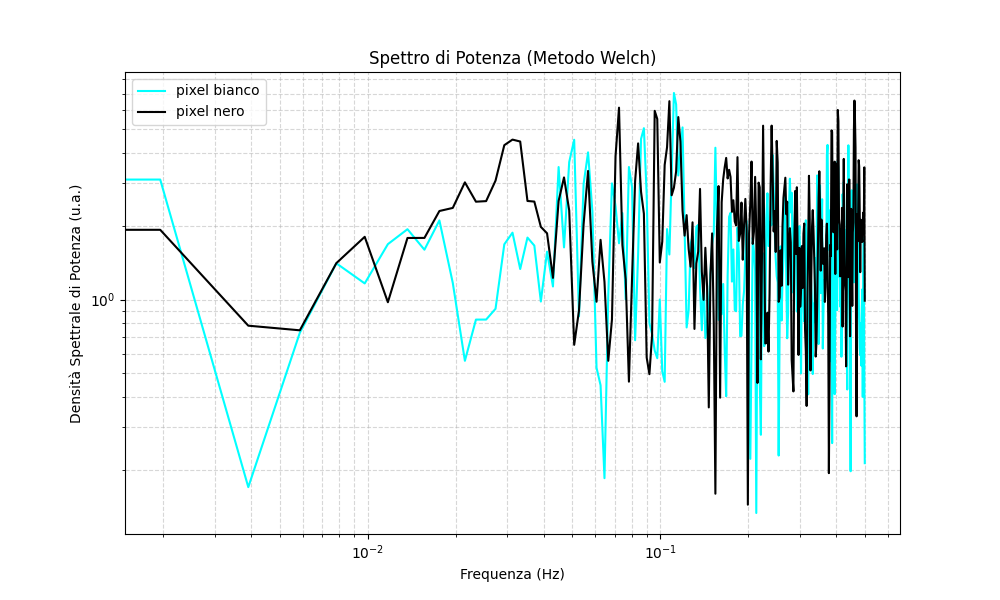

In [9]:
plt.figure(figsize=(10, 6))

# Usa loglog escludendo il primo punto (frequenza 0) se presente, proprio come prima
plt.loglog(frequenze_welch_b, powerspectrum_welch_b, label='pixel bianco', color='cyan')
plt.loglog(frequenze_welch_n, powerspectrum_welch_n, label='pixel nero', color='black')

plt.xlabel('Frequenza (Hz)')
plt.ylabel('Densità Spettrale di Potenza (u.a.)')
plt.title('Spettro di Potenza (Metodo Welch)')
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend()
plt.show()

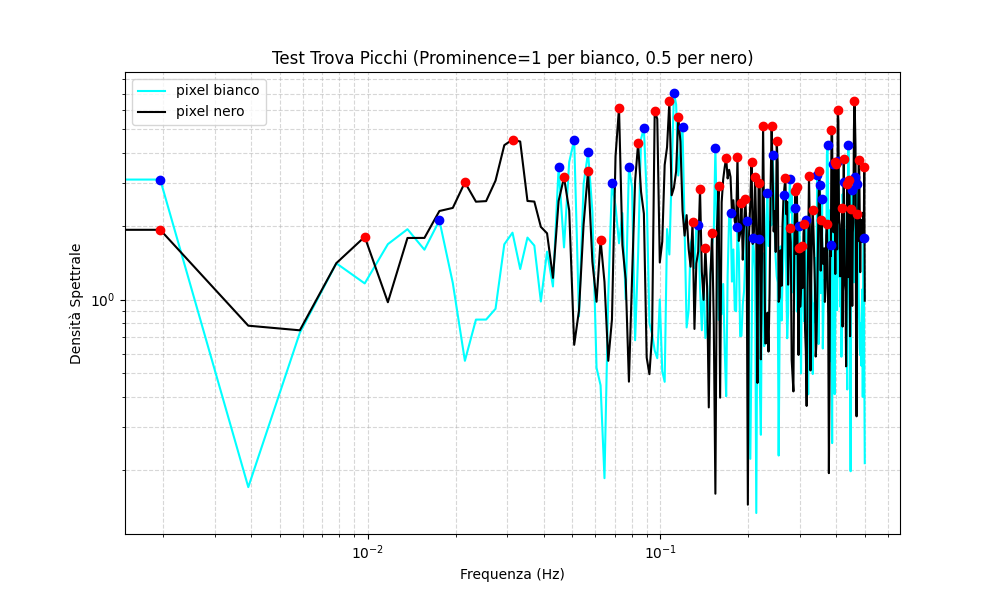

Frequenze dei picchi trovate pixel bianco: [0.00195312 0.01757812 0.04492188 0.05078125 0.05664062 0.06835938
 0.078125   0.08789062 0.11132812 0.11914062 0.13476562 0.15429688
 0.17382812 0.18359375 0.19726562 0.20703125 0.21679688 0.23242188
 0.2421875  0.265625   0.27734375 0.2890625  0.29882812 0.31445312
 0.34375    0.3515625  0.35742188 0.37304688 0.3828125  0.390625
 0.40429688 0.42382812 0.43945312 0.45117188 0.46289062 0.47070312
 0.49609375]
Frequenze dei picchi trovate pixel nero: [0.00195312 0.00976562 0.02148438 0.03125    0.046875   0.05664062
 0.0625     0.07226562 0.08398438 0.09570312 0.10742188 0.11523438
 0.12890625 0.13671875 0.14257812 0.15039062 0.15820312 0.16796875
 0.18359375 0.18945312 0.1953125  0.20507812 0.2109375  0.21679688
 0.22460938 0.24023438 0.25       0.26757812 0.27734375 0.2890625
 0.29296875 0.29882812 0.3046875  0.31054688 0.32226562 0.33203125
 0.34960938 0.35546875 0.37109375 0.38476562 0.39453125 0.3984375
 0.40429688 0.41796875 0.42382812 0.

In [10]:
# Assicurati di cercare i picchi sul LOGARITMO del power spectrum se noti che le oscillazioni a bassa frequenza sono numericamente giganti rispetto a quelle ad alta frequenza,
# oppure cercali direttamente sul vettore ottenuto con Welch.
#segnale = powerspectrum_welch_b

soglia_prominence_b = 1
soglia_prominence_n = 0.5 

indici_picchi_b, properties_b = find_peaks(powerspectrum_welch_b, prominence=soglia_prominence_b)
indici_picchi_n, properties_n = find_peaks(powerspectrum_welch_n, prominence=soglia_prominence_n)

plt.figure(figsize=(10, 6))
plt.loglog(frequenze_welch_b, powerspectrum_welch_b, label='pixel bianco', color='cyan')
plt.loglog(frequenze_welch_n, powerspectrum_welch_n, label='pixel nero', color='black')

plt.loglog(frequenze_welch_b[indici_picchi_b], powerspectrum_welch_b[indici_picchi_b], "bo")
plt.loglog(frequenze_welch_n[indici_picchi_n], powerspectrum_welch_n[indici_picchi_n], "ro")

plt.title(f'Test Trova Picchi (Prominence={soglia_prominence_b} per bianco, {soglia_prominence_n} per nero)')
plt.xlabel('Frequenza (Hz)')
plt.ylabel('Densità Spettrale')
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend()
plt.show()

print("Frequenze dei picchi trovate pixel bianco:", frequenze_welch_b[indici_picchi_b])
print("Frequenze dei picchi trovate pixel nero:", frequenze_welch_n[indici_picchi_n])

In [11]:
fs=1.0/np.mean(np.diff(image_seconds))
fn = fs/2 #frequenza di Nyquist
print("Frequenza di campionamento (fs):", fs)

"""f = [frequenze_welch_b + k*fs for k in range(-1, 2)] # Considera anche le frequenze aliasate a fs-k*fn e fs+k*fn
f = np.array(f) 
#print(f) 
for i in range(len(f)):
    if f[i] < fn:
        print("Frequenze dei picchi trovate pixel bianco (considerando aliasing):", f[i])"""

Frequenza di campionamento (fs): 1.0


'f = [frequenze_welch_b + k*fs for k in range(-1, 2)] # Considera anche le frequenze aliasate a fs-k*fn e fs+k*fn\nf = np.array(f) \n#print(f) \nfor i in range(len(f)):\n    if f[i] < fn:\n        print("Frequenze dei picchi trovate pixel bianco (considerando aliasing):", f[i])'

In [12]:
print(powerspectrum_bianco.shape)
print(frequenze_bianco.shape)

print(powerspectrum_nero.shape)
print(frequenze_nero.shape)

NameError: name 'powerspectrum_bianco' is not defined

In [ ]:
plt.figure(figsize=(10,6))

#for i in range(len(powerspectrum)):
plt.loglog(frequenze_bianco, powerspectrum_bianco, color='cyan')
plt.loglog(frequenze_nero, powerspectrum_nero, color='black')
#plt.yscale('log')
plt.xlabel('Frequenza (Hz)')
plt.ylabel('Potenza (u.a.)')
plt.title('Power Spectrum')
plt.grid(True, which='both', ls='--', lw=0.5)
plt.legend(['Bianco', 'Nero'])
plt.show()

In [14]:
#images_arr = np.array(images)

step = 10

images_stepped = images_arr[:, ::step, ::step]
images_final = images_stepped[2700:2765]

intensita_pixel = images_final.reshape(images_final.shape[0], -1).T
#questa matrice ha forma (num_pixel, num_frames), dove ogni riga contiene l'intensità di un pixel attraverso tutti i frames

fft_pixel = np.fft.rfft(intensita_pixel, axis=1)
powerspectrum = np.abs(fft_pixel)**2

frequenze = np.fft.rfftfreq(intensita_pixel.shape[1], d=np.mean(np.diff(image_seconds)))
# d è il tempo di campionamento

ValueError: cannot reshape array of size 0 into shape (0,newaxis)

In [ ]:
print(images_final.shape)
print(powerspectrum.shape)
print(frequenze.shape)

In [15]:
half_points = len(frequenze) // 2

frequenze = frequenze[1:half_points]
powerspectrum = powerspectrum[:, 1:half_points]

plt.figure(figsize=(10, 6))

colori = plt.cm.jet(np.linspace(0, 1, powerspectrum.shape[0]))

for i in range(powerspectrum.shape[0]):
    plt.loglog(frequenze, powerspectrum[i], alpha=0.2, color=colori[i])
    
plt.title('Power Spectrum of Pixel Intensity', fontsize=16)
plt.xlabel('Frequency (Hz)', fontsize=14)
plt.ylabel('Power', fontsize=14)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.show()

NameError: name 'frequenze' is not defined